# Example: Shot-noise template with RIC and AMR on the QSO autocorrelation

The conventional shot noise of a power spectrum measurement is a constant. Once the weights go through the observational effects that are forward modeled in `desiwinds.forward` (RIC, AMR, the global integral constraint, ...), the shot noise contribution to the measured multipoles is instead this constant times a dimensionless, scale-dependent **shot-noise template** $s_\ell(k)$, which can be nonzero at low $k$ for $\ell > 0$.

This notebook computes that template:
* analytically, for the survey geometry alone and for the geometry with the global integral constraint (`analytic_shotnoise_template`),
* by sampling, with RIC and AMR, with `sample_shotnoise_template_linearized`, with and without a control variate built from the analytic template (`shotnoise_template_with_control_variate`).

The "data" is a random half of the randoms, so there is no clustering. The sampling injects independent noise on the weights of the data and propagates it through the whole pipeline.

In [1]:
import sys
sys.path.insert(0, "/global/homes/d/dchebat/window/desiwinds/src/")
import desiwinds

In [2]:
import itertools
import time
from pathlib import Path

import healpy as hp
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jaxpower import BinMesh2SpectrumPoles, FKPField, compute_fkp2_normalization, get_mesh_attrs

from desiwinds.convenience import get_randoms, get_sysmap, split_into_fields
from desiwinds.forward import prepare_AMR, prepare_RIC
from desiwinds.shotnoise import (
    analytic_shotnoise_template,
    combine_regions_weighted_by_normalization,
    get_estimator_normalizations,
    measure_power_spectrum_and_shotnoise,
    prepare_field_weights,
    sample_shotnoise_template_linearized,
    shotnoise_template_from_samples,
    shotnoise_template_uncertainty,
    shotnoise_template_with_control_variate,
)

## Parameters
Adjust data paths and redshift ranges to match your environment.

In [3]:
LOS = "local"
n_real = 16  # number of realizations of the noise

n_randoms = 1

boxsize = 10000.0
cellsize = 20.0

tracer = "QSO"
z_range = (0.8, 1.3)

pk_regions = ["SGC", "NGC"]
photo_regions = ["N", "SnoDES", "DES"]  # Photometric regions for QSO
z_ranges = [(0.8, 1.3)]  # Redshift ranges for the angular systematics regression

data_to_randoms = 0.5  # Use 50% of the randoms catalogs as "data" and the rest as randoms

regression_maps = ['PSFDEPTH_W1', 'PSFDEPTH_W2', 'STARDENS', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'EBV_DIFF_GR', 'EBV_DIFF_RZ', 'HI']

randoms_basedir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/fNL")
templates_dir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/hpmaps/")
ebvdir = Path("/dvs_ro/cfs/cdirs/desicollab/users/rongpu/data/ebv/desi_stars_y3/v0.1/final_maps/lss/")

## Load randoms and create catalogs

### Imaging templates

In [4]:
sysmaps_south = get_sysmap(
    map_path=Path(
        templates_dir / f"{tracer}_mapprops_healpix_nested_nside256_S.fits"
    ),
    region="S",
    ebv_path=ebvdir / "desi_ebv_lss_256.fits",
)
sysmaps_south.keep_columns(regression_maps)
sysmaps_south = np.lib.recfunctions.structured_to_unstructured(
    sysmaps_south.as_array()
).astype(float)

sysmaps_north = get_sysmap(
    map_path=Path(
        templates_dir / f"{tracer}_mapprops_healpix_nested_nside256_N.fits"
    ),
    region="N",
    ebv_path=ebvdir / "desi_ebv_lss_256.fits",
)
sysmaps_north.keep_columns(regression_maps)
sysmaps_north = np.lib.recfunctions.structured_to_unstructured(
    sysmaps_north.as_array()
).astype(float)

sysmaps = np.where(sysmaps_south == 0.0, sysmaps_north, sysmaps_south)
sysmapsnan = np.where(sysmaps == 0.0, np.nan, sysmaps)

sysmaps -= np.nanmean(sysmapsnan, axis=0)
sysmaps /= np.nanstd(sysmapsnan, axis=0)

del sysmaps_south, sysmaps_north, sysmapsnan

### Randoms catalogs

In [5]:
fkp_fields = []
fkp_norms = []

data = []
randoms = []

for pk_region in pk_regions:
    # Load data for single tracer
    position, [weight, weight_FKP], redshift = get_randoms(
        n_randoms,
        pk_region,
        z_range,
        tracer,
        "FKP",
        basedir=randoms_basedir,
        return_redshift=True,
    )

    template_values = sysmaps[hp.vec2pix(256, *position.T, nest=True)]

    # Create mesh attributes
    mattrs = get_mesh_attrs(position, cellsize=cellsize, boxsize=boxsize, check=True)

    # Create data/randoms split
    _data, _randoms, _mask_is_data = split_into_fields(
        position,
        weight,
        extra={"Z": redshift, "weight_FKP": weight_FKP, "template_values":template_values},
        data_size=int(weight.shape[0] * data_to_randoms),
        split_seed=123,
        mattrs=mattrs,
        exchange=True,
        backend="jax",
    )

    data.append(_data)
    randoms.append(_randoms)

    # Create FKP field
    fkp_field = FKPField(data=_data, randoms=_randoms, attrs=mattrs)
    fkp_fields.append(fkp_field)

    # Compute normalization
    binner = BinMesh2SpectrumPoles(mattrs=mattrs, edges={"min": 0.001, "step": 0.001}, ells=(0, 2, 4))
    fkp_norm = compute_fkp2_normalization(fkp_field, bin=binner, cellsize=20.0)
    fkp_norms.append(fkp_norm)

    del position, weight, weight_FKP, redshift, template_values, _mask_is_data, _data, _randoms
del sysmaps

## Build RIC and AMR arguments

In [6]:
ric_args = prepare_RIC(
    data=tuple(data), # i.e. (data_sgc, data_ngc)
    randoms=tuple(randoms), # i.e. (randoms_sgc, randoms_ngc)
    regions=photo_regions,
    n_bins=1000,
    apply_to="randoms",
)

jax.block_until_ready(ric_args);

In [7]:
amr_args = prepare_AMR(
    data=tuple(data), # i.e. (data_sgc, data_ngc)
    randoms=tuple(randoms), # i.e. (randoms_sgc, randoms_ngc)
    regions_zranges=list(itertools.product(photo_regions, z_ranges)),
    apply_to="randoms",
    half_precision=True,
)

jax.block_until_ready(amr_args);

In [8]:
for i in range(len(fkp_fields)):
    fkp_fields[i] = fkp_fields[i].clone(
        data=fkp_fields[i].data.clone(
            extra={k:fkp_fields[i].data.extra[k] for k in fkp_fields[i].data.extra.keys() - {"template_values", "Z"}},
        ),
        randoms=fkp_fields[i].randoms.clone(
            extra={k:fkp_fields[i].randoms.extra[k] for k in fkp_fields[i].randoms.extra.keys() - {"template_values", "Z"}},
        )
    )

## Weights of the measured field

`prepare_field_weights` gathers what is needed to compute the weights of the field that enters the power spectrum estimator (the data minus $\alpha$ times the randoms): the input weights of the data and of the randoms, the frozen estimator weights (here the FKP weights), and the effects to apply to the weights.

We build it for three pipelines: the geometry alone, with the global integral constraint (the ratio $\alpha$ of the data to randoms weights responds to the data weights), and with RIC and AMR on top of it.

In [9]:
weights_args_geometry = prepare_field_weights(*fkp_fields, estimator_weights="weight_FKP", gic=False)

weights_args_gic = prepare_field_weights(*fkp_fields, estimator_weights="weight_FKP", gic=True)

weights_args_ric_amr = prepare_field_weights(
    *fkp_fields,
    estimator_weights="weight_FKP",
    ric_args=ric_args,
    amr_args=amr_args,
    data_regions=ric_args.data_regions,
    randoms_regions=ric_args.randoms_regions,
)

Arguments of the power spectrum estimation that are common to all the following calls, and the estimator normalization of each region (used to combine the regions as the data measurement does):

In [10]:
estimator_kwargs = dict(binner=binner, fkp_norms=fkp_norms, los=LOS)

norms = np.asarray(get_estimator_normalizations(fkp_norms))
k = np.asarray(binner.xavg)

In [11]:
def combine(spectrum_response, shotnoise_response):
    """Template of the combined regions from the responses of each region."""
    numerator, denominator = combine_regions_weighted_by_normalization(np.asarray(spectrum_response)[None], np.asarray(shotnoise_response)[None], norms)
    return numerator[0] / denominator[0]


def plot_templates(entries, title):
    """Plot the (label, template, uncertainty) entries, for each multipole."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, layout="constrained")
    for i, (ax, ell) in enumerate(zip(axes, binner.ells)):
        for offset, (label, template, uncertainty) in enumerate(entries):
            ax.errorbar(k * (1 + 0.01 * offset), template[i], None if uncertainty is None else uncertainty[i], marker=".", ms=3, capsize=1.5, label=label)
        ax.set_title(rf"$\ell = {ell}$")
        ax.set_xlabel("$k$ [h/Mpc]")
        ax.set_xscale("log")
    axes[0].set_ylabel(r"shot-noise template $s_\ell(k)$")
    axes[0].legend(fontsize=8)
    fig.suptitle(title)

## Analytic template

For the geometry alone, and for the geometry with the global integral constraint, the template has a closed form. `analytic_shotnoise_template` returns, for each region, the response of the power spectrum, the response of the conventional shot noise, and their ratio.

In [12]:
spectrum_response_geometry, shotnoise_response_geometry, _ = analytic_shotnoise_template(
    *fkp_fields, field_weights_args=weights_args_geometry, include_gic=False, **estimator_kwargs
)

analytic_spectrum_response, analytic_shotnoise_response, _ = analytic_shotnoise_template(
    *fkp_fields, field_weights_args=weights_args_gic, include_gic=True, **estimator_kwargs
)

analytic_geometry = combine(spectrum_response_geometry, shotnoise_response_geometry)
analytic_gic = combine(analytic_spectrum_response, analytic_shotnoise_response)

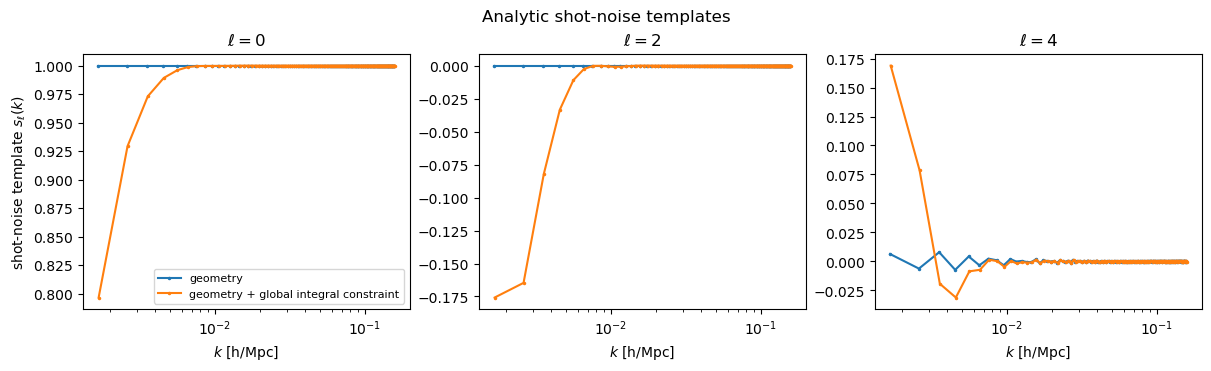

In [13]:
plot_templates(
    [("geometry", analytic_geometry, None), ("geometry + global integral constraint", analytic_gic, None)],
    "Analytic shot-noise templates",
)

Without any effect that cannot be treated analytically, the geometry gives $s_0 = 1$ and no signal for $\ell > 0$ beyond the anisotropy of the Fourier grid; the global integral constraint removes shot noise at the lowest $k$.

## Sampling the template with RIC and AMR

With RIC and AMR (which regress on the data weights themselves), there is no closed form. The template is sampled by injecting independent noise on the weights of the data and propagating it through the pipeline. `sample_shotnoise_template_linearized` differentiates the pipeline in forward mode, which gives the response of the weights of the field to the noise at linear order, with no noise amplitude to choose. It is a single jitted function, with a `jax.lax.map` over the realizations, and returns the per-realization responses of the power spectrum and of the conventional shot noise; their ratio of means is the template (`shotnoise_template_from_samples`).

With `compute_control_variate=True`, it also stores the response of a simplified pipeline (only $\alpha$ reacts) to the same noise draws, whose expectation is known analytically.

Two other sampling methods are available with the same arguments: `sample_shotnoise_template_antithetic` (noise injected with opposite signs on the whole pipeline, biased at order `sigma**2`) and `sample_shotnoise_template_quadratic` (nested derivatives, which also keep the curvature of the pipeline). They give the same template here, at a higher cost.

In [14]:
start = time.perf_counter()
samples = jax.block_until_ready(
    sample_shotnoise_template_linearized(
        *fkp_fields,
        field_weights_args=weights_args_ric_amr,
        key=jax.random.key(42),
        n_real=n_real,
        compute_control_variate=True,
        **estimator_kwargs,
    )
)
print(f"{n_real} realizations in {time.perf_counter() - start:.1f} s (including compilation)")

16 realizations in 65.1 s (including compilation)


In [15]:
template, covariance = shotnoise_template_from_samples(samples, norms)
uncertainty = shotnoise_template_uncertainty(samples, norms)

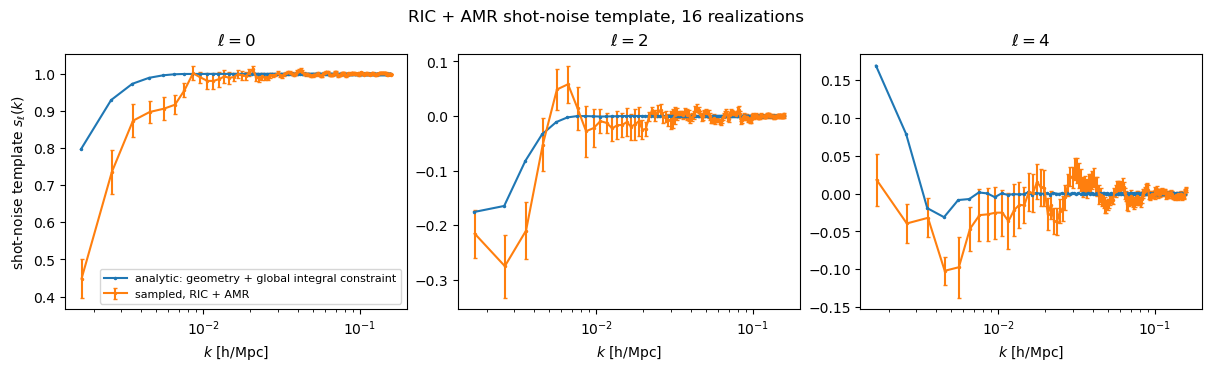

In [16]:
plot_templates(
    [
        ("analytic: geometry + global integral constraint", analytic_gic, None),
        ("sampled, RIC + AMR", template, uncertainty),
    ],
    f"RIC + AMR shot-noise template, {n_real} realizations",
)

## Control variate

The analytic template with the global integral constraint is exact for the simplified pipeline. Its response to each noise draw is correlated with that of the full pipeline, so subtracting it (minus its known expectation) reduces the Monte Carlo noise without bias. The coefficient is either fixed to 1 or fitted from the draws, per bin.

In [17]:
template_cv_fit, covariance_cv_fit, diagnostics_fit = shotnoise_template_with_control_variate(
    samples, norms, analytic_spectrum_response, analytic_shotnoise_response, coefficient="fit"
)
uncertainty_cv_fit = np.sqrt(np.diag(covariance_cv_fit)).reshape(template.shape)

template_cv_fix, covariance_cv_fix, diagnostics_fix = shotnoise_template_with_control_variate(
    samples, norms, analytic_spectrum_response, analytic_shotnoise_response, coefficient=1.
)
uncertainty_cv_fix = np.sqrt(np.diag(covariance_cv_fix)).reshape(template.shape)

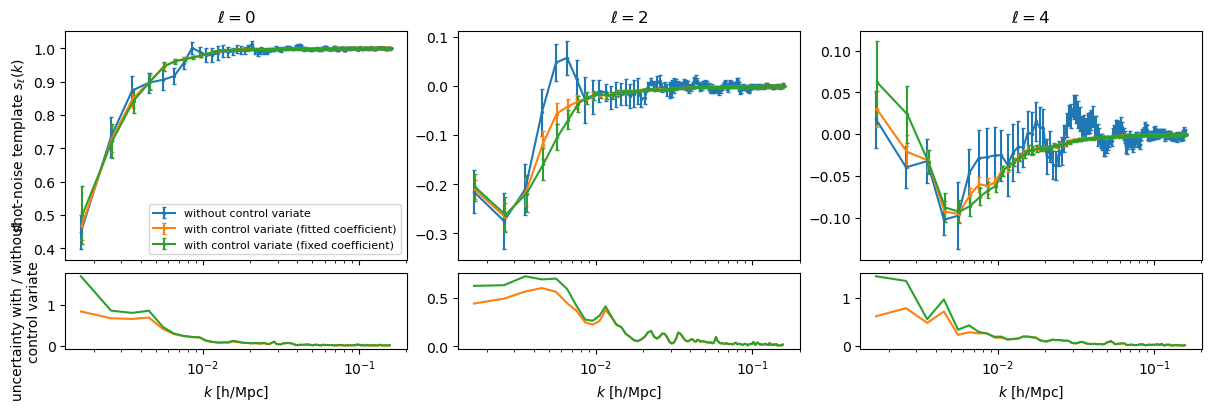

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 4), sharex=True, layout="constrained", height_ratios=[3, 1])
for i, ell in enumerate(binner.ells):
    axes[0, i].errorbar(k, template[i], uncertainty[i], marker=".", ms=3, capsize=1.5, label="without control variate")
    axes[0, i].errorbar(k * 1.01, template_cv_fit[i], uncertainty_cv_fit[i], marker=".", ms=3, capsize=1.5, label="with control variate (fitted coefficient)")
    axes[0, i].errorbar(k * 1.02, template_cv_fix[i], uncertainty_cv_fix[i], marker=".", ms=3, capsize=1.5, label="with control variate (fixed coefficient)")
    axes[1, i].plot(k, uncertainty_cv_fit[i] / uncertainty[i], color="C1")
    axes[1, i].plot(k, uncertainty_cv_fix[i] / uncertainty[i], color="C2")
    axes[0, i].set_title(rf"$\ell = {ell}$")
    axes[1, i].set_xlabel("$k$ [h/Mpc]")
    axes[1, i].set_xscale("log")
axes[0, 0].set_ylabel(r"shot-noise template $s_\ell(k)$")
axes[1, 0].set_ylabel("uncertainty with / without\ncontrol variate")
axes[0, 0].legend(fontsize=8)

The two estimates agree within their uncertainties, and the control variate reduces the uncertainty, mostly at high $k$, where the pipeline is close to the simplified one. Its cost is one more painting and spectrum per realization.

## Using the template

The shot noise contribution to the measured multipoles is the conventional shot noise of the data monopole times the template. `measure_power_spectrum_and_shotnoise` gives the unsubtracted power spectrum of the noise-free pipeline and the conventional shot noise. Since this "data" is unclustered, the unsubtracted spectrum of this one catalog is itself a measurement of the shot noise, to compare with the prediction. It is a single realization of the catalog, so it scatters around the prediction (more at low $k$, where there are fewer modes), and it is not a fit:

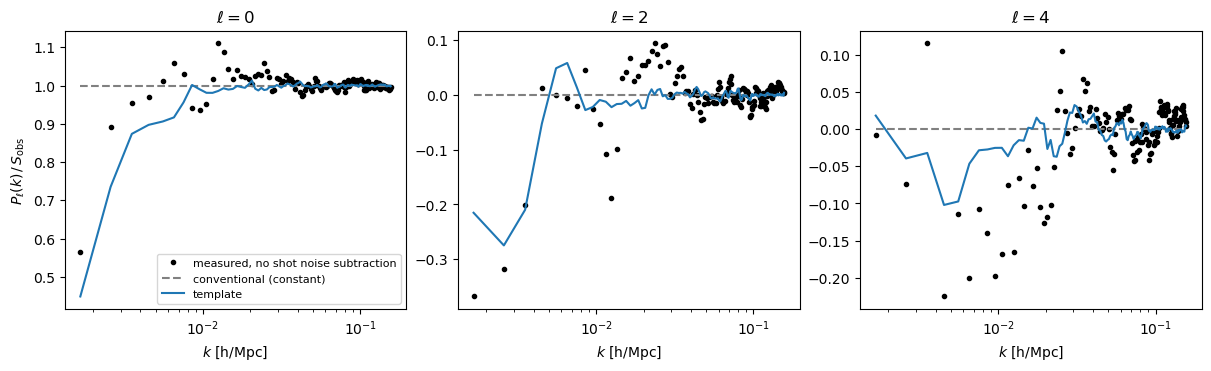

In [19]:
unsubtracted_spectrum, conventional_shotnoise = measure_power_spectrum_and_shotnoise(
    *fkp_fields, field_weights_args=weights_args_ric_amr, **estimator_kwargs
)

# combine the regions as the data measurement does
measured, shotnoise_observed = combine_regions_weighted_by_normalization(np.asarray(unsubtracted_spectrum)[None], np.asarray(conventional_shotnoise)[None], norms)
measured, shotnoise_observed = measured[0] / norms.sum(), shotnoise_observed[0] / norms.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, layout="constrained")
for i, (ax, ell) in enumerate(zip(axes, binner.ells)):
    ax.plot(k, measured[i] / shotnoise_observed, "k.", label="measured, no shot noise subtraction")
    ax.plot(k, np.full_like(k, float(ell == 0)), "--", color="grey", label="conventional (constant)")
    ax.plot(k, template[i], label="template")
    ax.set_title(rf"$\ell = {ell}$")
    ax.set_xlabel("$k$ [h/Mpc]")
    ax.set_xscale("log")
axes[0].set_ylabel(r"$P_\ell(k)\,/\,S_\mathrm{obs}$")
axes[0].legend(fontsize=8)

Fit either the unsubtracted measurement with the model $\sum_{\ell'} W_{\ell\ell'} P^\mathrm{th}_{\ell'} + (1 + \alpha_0)\, S_\mathrm{obs}\, s_\ell(k)$, or the measurement with $S_\mathrm{obs}\, s_\ell(k)$ subtracted with the excess modeled as $\alpha_0\, S_\mathrm{obs}\, s_\ell(k)$, where $\alpha_0$ is a free non-Poisson nuisance parameter.

## Batching the realizations

Each sampling function takes a `batch_size`: the number of realizations evaluated in parallel by `jax.lax.map` (by default one after the other). It speeds things up at the price of memory, which grows with it. Memory is dominated by the meshes and by the derivatives of the pipeline, so choose it according to your mesh and catalog sizes.